In [1]:
import sys, os
from pathlib import Path

parent_folder = str(Path.cwd().parents[2])
if parent_folder not in sys.path:
    sys.path.append(parent_folder)
from sigpy import mri
import scipy
import pickle
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap
import seaborn as sns
import sigpy as sp
import cupy as cp
import numpy as np
from sigpy.mri.app import TotalVariationRecon


## My files
import save_data_helpers
import recon_functions
import recon_plot_helpers
from gating_functions import golden_angle_coords_3d
import sigpy.plot as pl

### Load data

In [2]:
ksp_512 = save_data_helpers.read_pickle('/home/lilianae/projects/naf_clean/load_data_clean/subject2_mid0082/ksp_from_mdb_512_samples.pkl')
ksp_512 = np.transpose(ksp_512, (2, 0, 1, 3))
print(f'ksp_512.shape = {ksp_512.shape}')

## Use first 400 spokes to speed up computation
ksp_data = ksp_512[:, :, :400, :]
print(f'ksp_data.shape = {ksp_data.shape}')

ncoils, nslices, nspokes, nsamples = ksp_data.shape
img_shape = (nslices, nsamples, nsamples)

## Golden angle coords
coords = golden_angle_coords_3d(img_shape=img_shape, num_spokes=nspokes, num_points=nsamples)
print(f'coords.shape = {coords.shape}')

espirit_mps = save_data_helpers.read_pickle('/home/lilianae/projects/naf_clean/coils/subject2_mid0082/espirit_mps_full_res_ksp_512_ungated.pkl')
print(f'espirit_mps.shape = {espirit_mps.shape}')

dcf_ksp = save_data_helpers.read_pickle('/home/lilianae/projects/naf_clean/recons/subject2_mid0082/pkl_files_512/dcf_ksp_less_spokes_512.pkl')
print(f'dcf_ksp.shape = {dcf_ksp.shape}')

ksp_with_dcf = ksp_data * dcf_ksp[None,:,:, :]
print(f'ksp_with_dcf.shape = {ksp_with_dcf.shape}')

ksp_512.shape = (15, 58, 2002, 512)
ksp_data.shape = (15, 58, 400, 512)
coords.shape = (58, 400, 512, 3)
espirit_mps.shape = (15, 58, 512, 512)
dcf_ksp.shape = (58, 400, 512)
ksp_with_dcf.shape = (15, 58, 400, 512)


### Helper function: Check data ranges

In [3]:
def check_data(data):
    """Print data ranges and dtype"""
    print(f"Step X - Shape: {data.shape}")
    print(f"  Real range: [{np.min(np.real(data))}, {np.max(np.real(data))}]")
    print(f"  Imag range: [{np.min(np.imag(data))}, {np.max(np.imag(data))}]")
    print(f"  Magnitude range: [{np.min(np.abs(data))}, {np.max(np.abs(data))}]")
    print(f"  Dtype: {data.dtype}")
    print(f"  Any NaN: {np.any(np.isnan(data))}, Any Inf: {np.any(np.isinf(data))}")


In [41]:
from __future__ import annotations

import sigpy
import numpy as np
import numpy.typing as npt
import cupy.typing as cpt
from scipy.signal import argrelextrema

def golden_angle_2d_readout(kmax: float, num_spokes: int,
                            num_points: int) -> npt.NDArray:
    """2D golden angle kspace trajectory

    Parameters
    ----------
    kmax : float
        maximum absolute k-space value
    num_spokes : int
        number of spokes (readout lines)
    num_points : int
        number of readout points per spoke

    Returns
    -------
    npt.NDArray
    """
    tmp = np.linspace(-kmax, kmax, num_points)
    k = np.zeros((num_spokes, num_points, 2))

    ga = np.pi / ((1 + np.sqrt(5)) / 2)

    for i in range(num_spokes):
        phi = (i * ga) % (2 * np.pi)
        k[i, :, 0] = tmp * np.cos(phi)
        k[i, :, 1] = tmp * np.sin(phi)

    return k


def stacked_nufft_operator(
        img_shape: tuple,
        coords: npt.NDArray | cpt.NDArray) -> sigpy.linop.Diag:
    """setup a stacked 2D NUFFT sigpy operator acting on a 3D image
       the opeator first performs a 1D FFT along the "z" axis (0 or left-most axis)
       followed by applying 2D NUFFTS to all "slices"
       
    Parameters
    ----------
        img_shape: tuple
            shape of the image
        coords: (numpy or cupy) array 
            coordinates of the k-space samples
            shape (n_k_space_points,2)
            units: "unitless" -> -N/2 ... N/2 at Nyquist (sigpy convention)

    Returns
    -------
        Diag: a stack of NUFFT operators
    """

    # setup the FFT operator along the "z" axis
    ft0_op = sigpy.linop.FFT(img_shape, axes=(0, ))

    # setup a 2D NUFFT operator for the start
    nufft_op = sigpy.linop.NUFFT(img_shape[1:], coords)

    # reshaping operators that remove / expand dimensions
    rs_in = sigpy.linop.Reshape(img_shape[1:], (1, ) + img_shape[1:])
    rs_out = sigpy.linop.Reshape((1, ) + tuple(nufft_op.oshape),
                                 nufft_op.oshape)

    # setup a list of "n" 2D NUFFT operators
    ops = img_shape[0] * [rs_out * nufft_op * rs_in]

    # apply 2D NUFFTs to all "slices" using the sigpy Diag operator
    return sigpy.linop.Diag(ops, iaxis=0, oaxis=0) * ft0_op



def stacked_nufft_operator_sens(
        img_shape: tuple,
        coords: npt.NDArray | cpt.NDArray,
        mps: npt.NDArray | cpt.NDArray) -> sigpy.linop.Diag:
    """setup a stacked 2D NUFFT sigpy operator acting on a 3D image
       the opeator first performs a 1D FFT along the "z" axis (0 or left-most axis)
       followed by applying 2D NUFFTS to all "slices"
       
    Parameters
    ----------
        img_shape: tuple
            shape of the image
        coords: (numpy or cupy) array 
            coordinates of the k-space samples
            shape (n_k_space_points,2)
            units: "unitless" -> -N/2 ... N/2 at Nyquist (sigpy convention)
        mps: (numpy or cupy) array
            sensitivity maps of shape (num_channels, *img_shape)

    Returns
    -------
        Diag: a stack of NUFFT operators
    """

    num_channels = len(mps)

    ft0_op = sigpy.linop.FFT(img_shape, axes=(0, ))

    # setup a 2D NUFFT operator for the start
    nufft_op = sigpy.linop.NUFFT(img_shape[1:], coords)

    # # reshaping operators that remove / expand dimensions
    # rs_in = sigpy.linop.Reshape(img_shape[1:], (1, ) + img_shape[1:])
    # rs_out = sigpy.linop.Reshape((1, ) + tuple(nufft_op.oshape),
    #                                 nufft_op.oshape)
    # reshaping operator for input
    rs_in = sigpy.linop.Reshape(img_shape[1:], (1, ) + img_shape[1:])
    # setup a list of "n" 2D NUFFT operators (one per slice)
    ops = []
    for i in range(img_shape[0]):
        coords_i = coords[i].reshape(-1, coords.shape[-1])[:, 1:]  # (400*512, 2)
        nufft_op_i = sigpy.linop.NUFFT(img_shape[1:], coords_i)
        # Reshape NUFFT output from flat to 2D: (400*512,) -> (400, 512)
        rs_nufft = sigpy.linop.Reshape((coords.shape[1], coords.shape[2]), nufft_op_i.oshape)
        rs_out_i = sigpy.linop.Reshape((1, coords.shape[1], coords.shape[2]), (coords.shape[1], coords.shape[2]))
        ops.append(rs_out_i * rs_nufft * nufft_op_i * rs_in)


    # setup a list of "n" 2D NUFFT operators
    # ops = img_shape[0] * [rs_out * nufft_op * rs_in]

    # apply 2D NUFFTs to all "slices" using the sigpy Diag operator
    full_op= sigpy.linop.Diag(ops, iaxis=0, oaxis=0) * ft0_op
    # full_op= sigpy.linop.Diag(ops, iaxis=0, oaxis=0) 
    #### Combine Sensitivity Op (mult with sens) and respective ft0+nuFFT op:

    #sensitivity = np.ones((num_channels,*img_shape),dtype=np.complex64)
    S = sigpy.linop.Multiply(img_shape,mps)

    rs_in_sense = sigpy.linop.Reshape(img_shape,(1,)+img_shape)
    rs_out_sense = sigpy.linop.Reshape((1,)+tuple(full_op.oshape),full_op.oshape)
    return  sigpy.linop.Diag(num_channels*[rs_out_sense*full_op*rs_in_sense],iaxis=0,oaxis=0)*S


### Try stacked NUFFT + SENSE

In [42]:
FS = stacked_nufft_operator_sens(img_shape=(58, 512, 512),
                                 coords=coords,
                                 mps=espirit_mps)

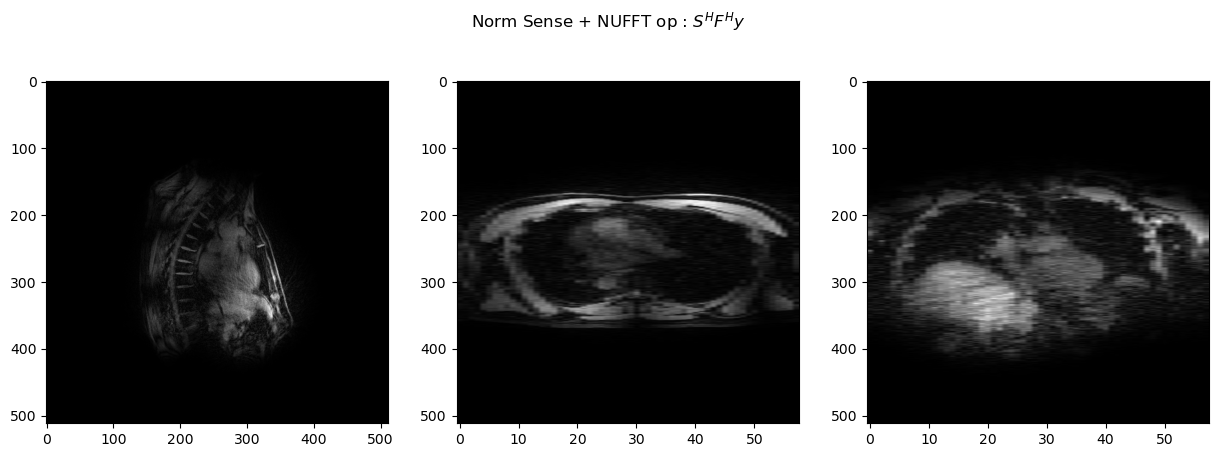

(<Figure size 1500x500 with 3 Axes>,
 array([<AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>], dtype=object))

In [47]:
img = np.abs(nufft_sense_stacked)
nufft_sense_stacked =  (img - np.min(img)) / (np.max(img) - np.min(img))
recon_plot_helpers.plot_recons_all_axes(np.abs(nufft_sense_stacked), title="Norm Sense + NUFFT op : $S^H F^H y$")

### 1. Sense/Multiply Linop

In [5]:
ncoils, nz, ny, nx = espirit_mps.shape

S = sp.linop.Multiply((nz, ny, nx), espirit_mps)

print(f'Input shape of Sense adjoint operator = {S.H.ishape}')
print(f'Output shape of Sense adjoint operator = {S.H.oshape}')

Input shape of Sense adjoint operator = [15, 58, 512, 512]
Output shape of Sense adjoint operator = [58, 512, 512]


### 2. NUFFT Linop

In [6]:
F = sp.linop.NUFFT((ncoils, nz, ny, nx), coord=coords)

print(f'Input shape of NUFFTAdjoint operator = {F.H.ishape}')
print(f'Output shape of NUFFTAdjoint operator = {F.H.oshape}')

Input shape of NUFFTAdjoint operator = [15, 58, 400, 512]
Output shape of NUFFTAdjoint operator = [15, 58, 512, 512]


In [7]:
nufft_images = F.H * ksp_with_dcf
print(f'nufft_images.shape = {nufft_images.shape}')
# Normalize first
# CORRECT - normalize each coil independently
nufft_images_norm = np.zeros_like(nufft_images)
for coil in range(nufft_images.shape[0]):  
    img = np.abs(nufft_images[coil])
    nufft_images_norm[coil] = (img - np.min(img)) / (np.max(img) - np.min(img))

nufft_images.shape = (15, 58, 512, 512)


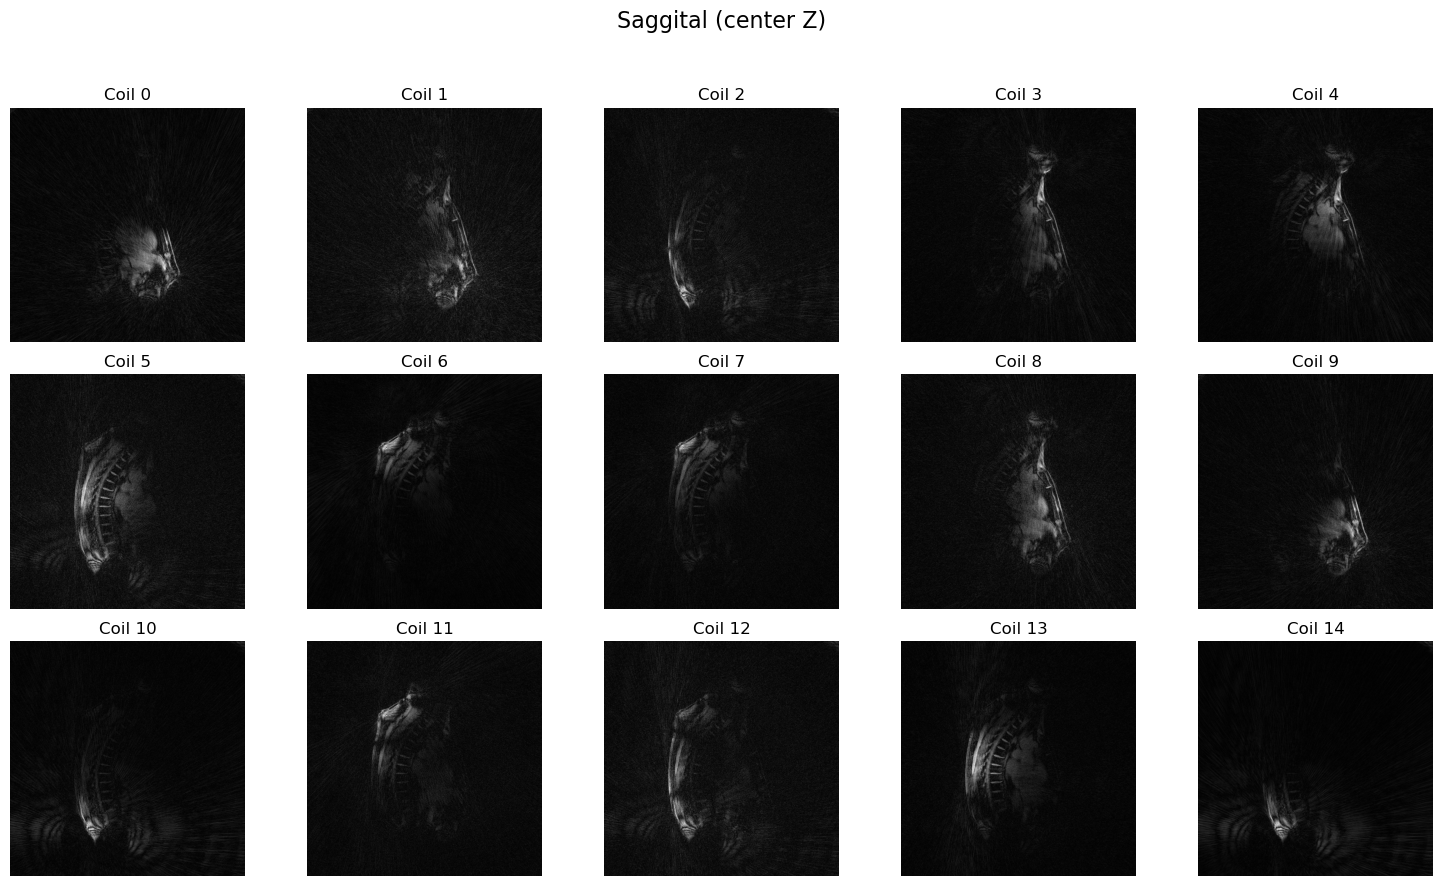

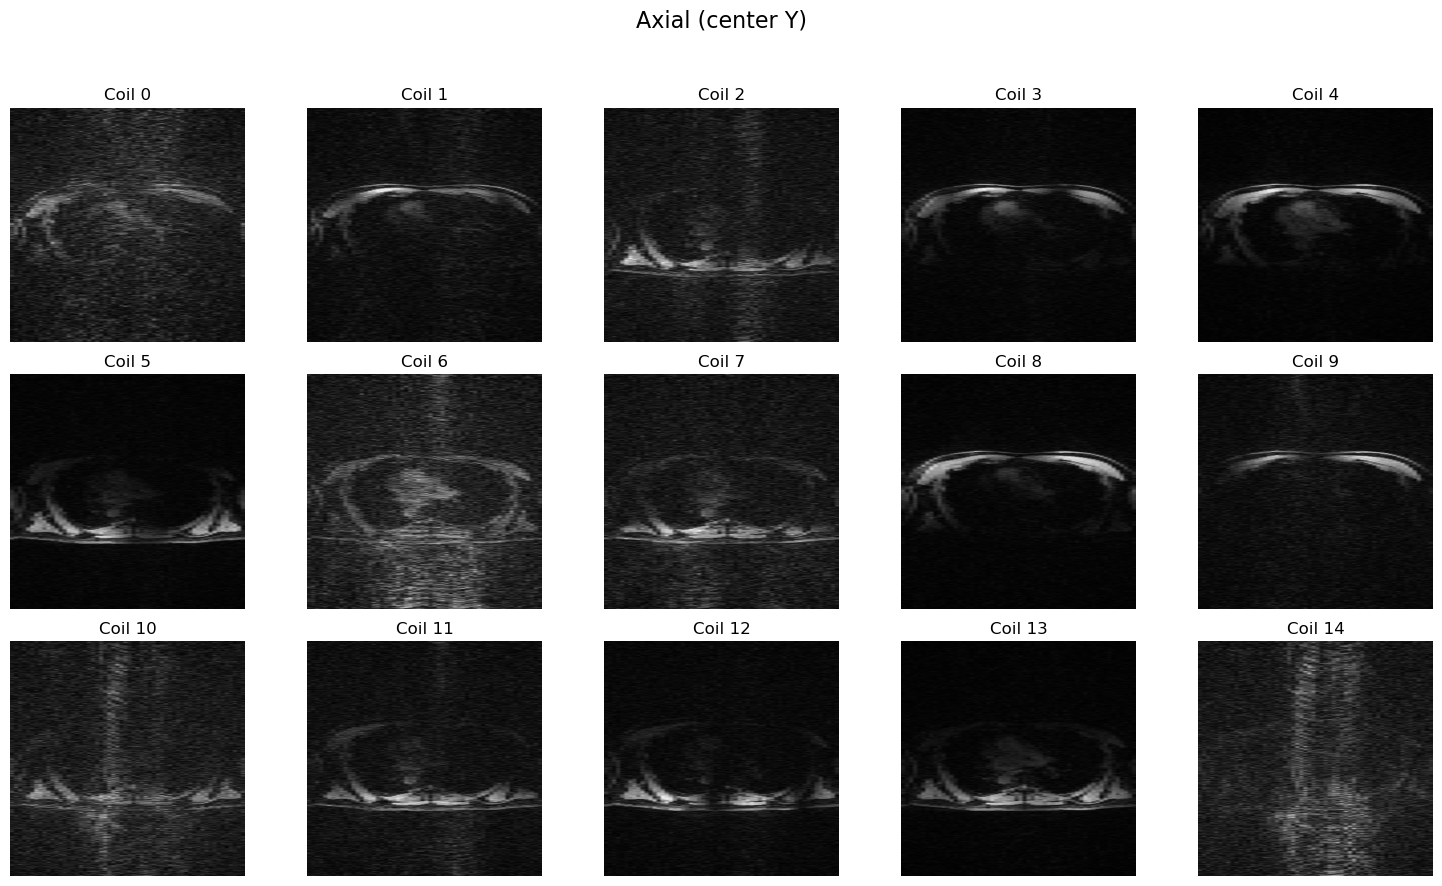

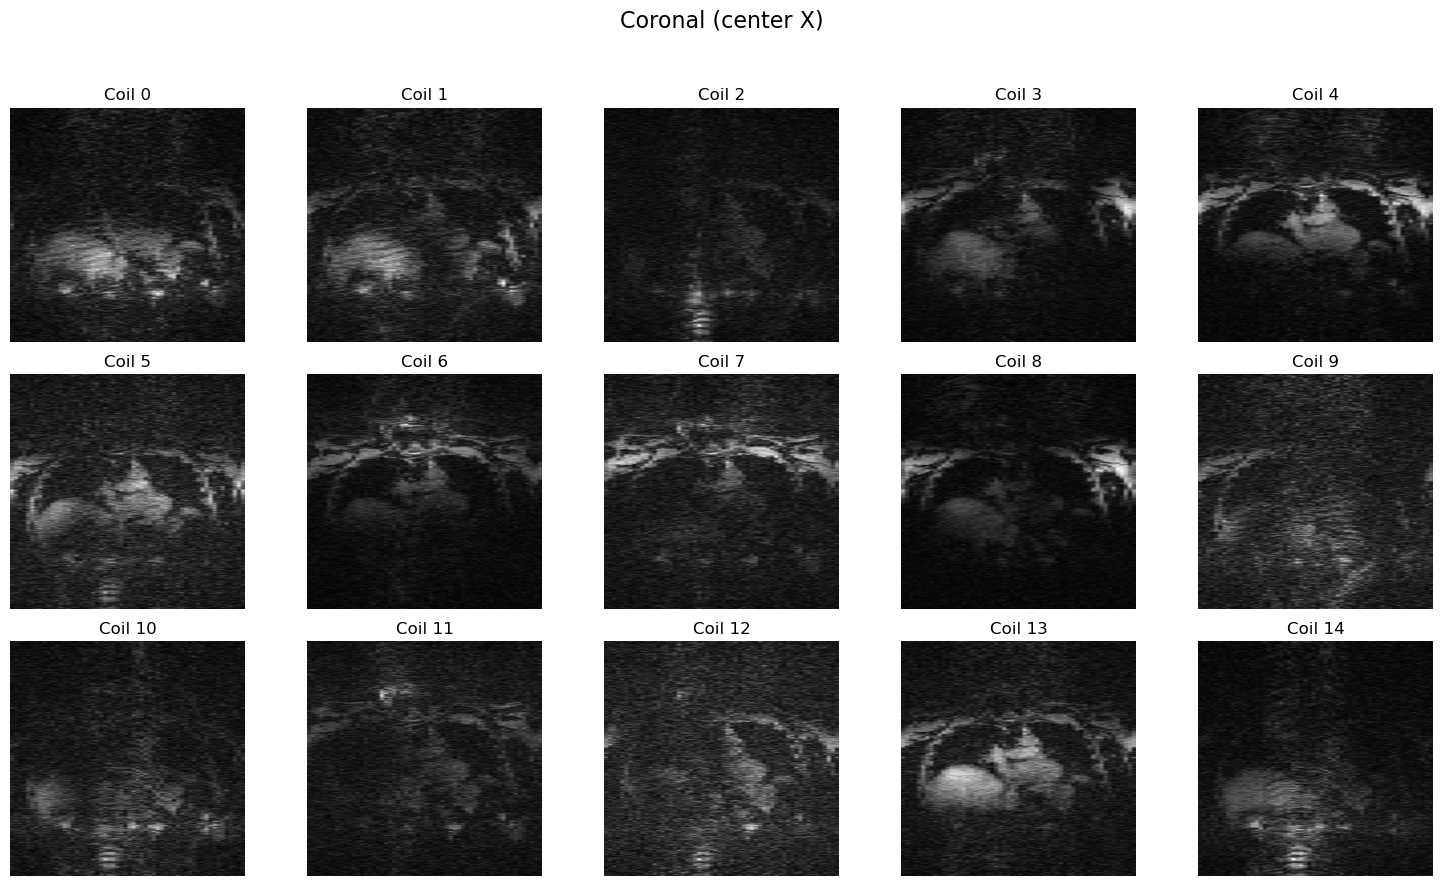

In [8]:
recon_plot_helpers.plot_center_slices(nufft_images_norm)

### NUFFT + SENSE

In [9]:
nufft_and_sense_images = S.H * nufft_images_norm

print(f'nufft_and_sense_images.shape = {nufft_and_sense_images.shape}')

img = np.abs(nufft_and_sense_images)
nufft_sense_norm =  (img - np.min(img)) / (np.max(img) - np.min(img))

nufft_and_sense_images.shape = (58, 512, 512)


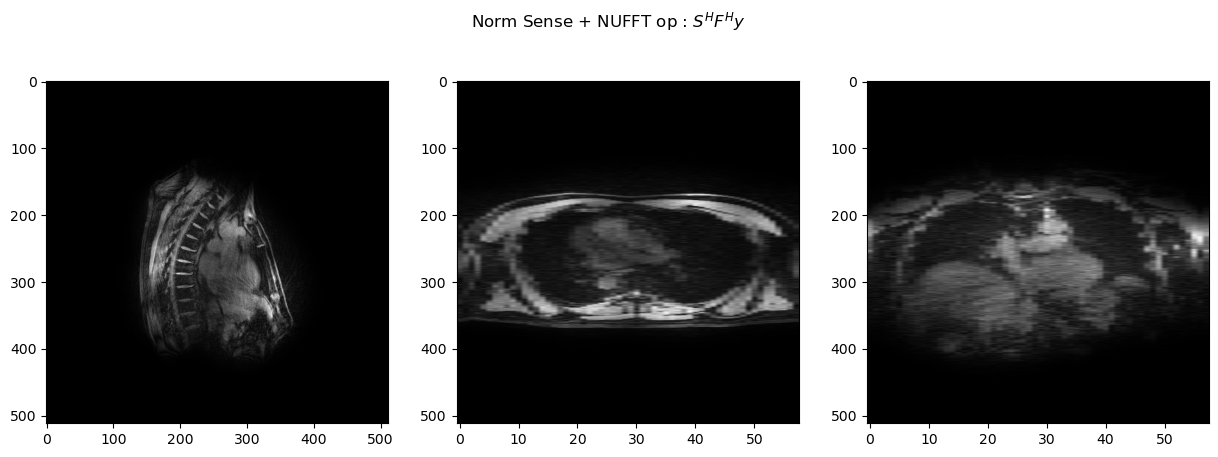

(<Figure size 1500x500 with 3 Axes>,
 array([<AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>], dtype=object))

In [10]:
recon_plot_helpers.plot_recons_all_axes(np.abs(nufft_sense_norm), title="Norm Sense + NUFFT op : $S^H F^H y$")

### A Operator

In [11]:
A_sense = F * S

### 4. G Operator

In [12]:
G = sp.linop.FiniteDifference(S.ishape)
grad_norm = G*nufft_sense_norm
print(f'G = {G}')
print(f'grad.shape = {grad_norm.shape}')


G = <[3, 58, 512, 512]x[58, 512, 512]> Vstack Linop>
grad.shape = (3, 58, 512, 512)


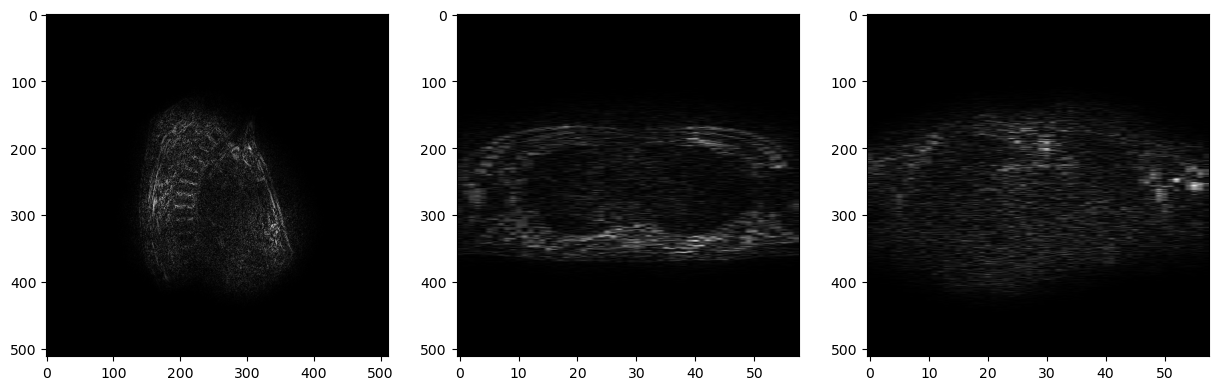

(<Figure size 1500x500 with 3 Axes>,
 array([<AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>], dtype=object))

In [13]:
img_back = G.H(grad_norm)
recon_plot_helpers.plot_recons_all_axes(img_back)

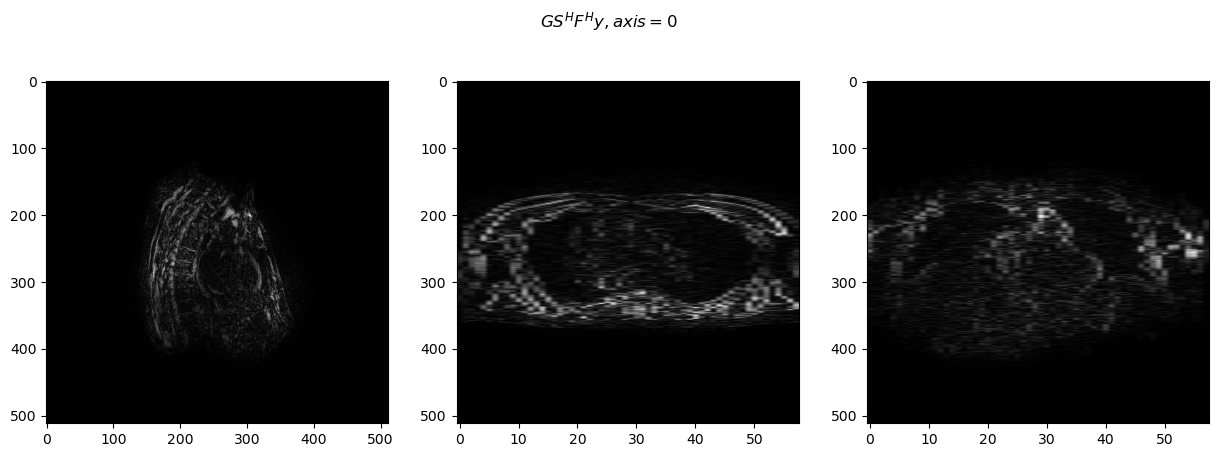

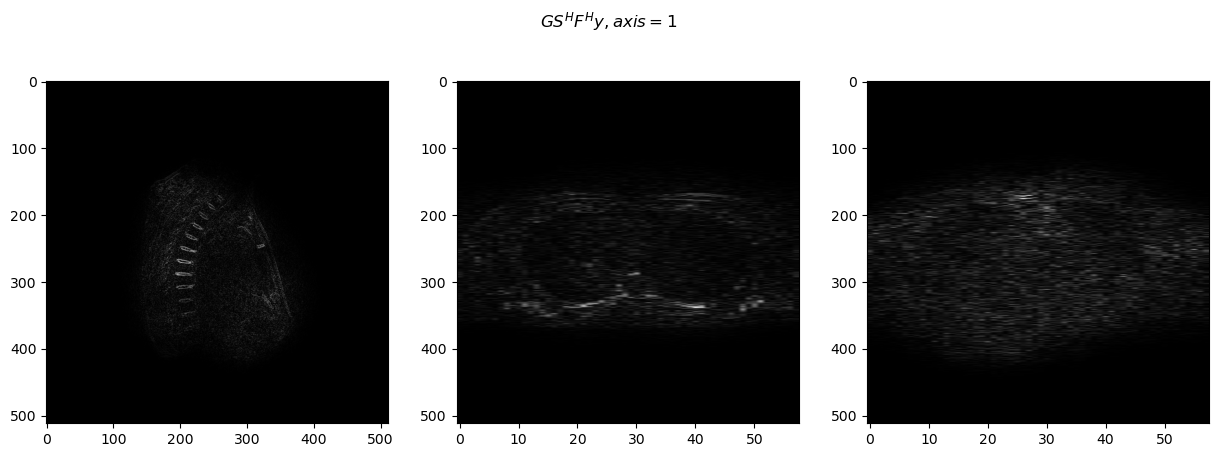

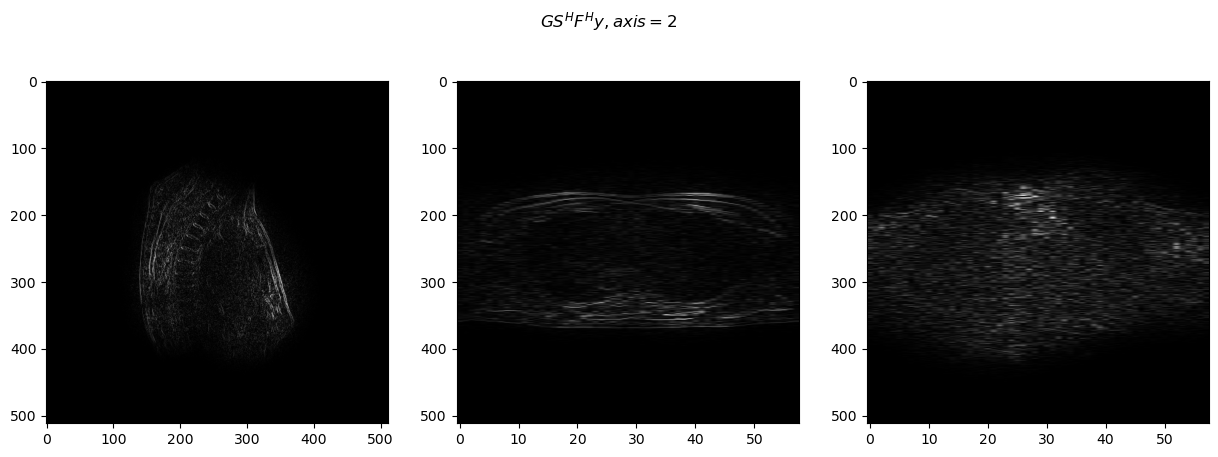

(<Figure size 1500x500 with 3 Axes>,
 array([<AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>], dtype=object))

In [14]:
recon_plot_helpers.plot_recons_all_axes(grad_norm[0], title="$G S^H F^H y, axis = 0 $")
recon_plot_helpers.plot_recons_all_axes(grad_norm[1], title="$G S^H F^H y, axis = 1 $")
recon_plot_helpers.plot_recons_all_axes(grad_norm[2], title="$G S^H F^H y, axis = 2 $")

In [81]:
y = ksp_with_dcf
x = ksp_with_dcf
z=np.zeros((58, 512, 512), dtype=np.complex64)
C = sp.linop.Vstack([A_sense, G])
print(f'C = {C}')
proxg = sp.prox.L1Reg(G.oshape, 1e-2)
proxg_ISSUE = sp.prox.L2Reg(x.shape, 1e-2,
                               y=z, proxh=proxg)
proxf1c = sp.prox.L2Reg(y.shape, 1, y=-y)
proxf2c = sp.prox.Conj(proxg_ISSUE)
proxg_ISSUE = sp.prox.L2Reg(x.shape, 1e-2,
                               y=z, proxh=proxg)
proxfc = sp.prox.Stack([proxf1c, proxf2c])

print(f'proxf1c = {proxf1c}')
print(f'proxg = {proxg}')
print(f'proxf2c = {proxf2c}')
print(f'proxfc = {proxfc}')
print(f'proxg_ISSUE = {proxg_ISSUE}')

C = <[223789056]x[58, 512, 512]> Vstack Linop>
proxf1c = <[15, 58, 400, 512] L2Reg Prox>.
proxg = <[3, 58, 512, 512] L1Reg Prox>.
proxf2c = <[15, 58, 400, 512] Conj Prox>.
proxfc = <[356352000] Stack Prox>.
proxg_ISSUE = <[15, 58, 400, 512] L2Reg Prox>.


In [78]:
# Your L2 bias of shape (58, 512, 512)
z = np.zeros((58, 512, 512), dtype=np.complex64)

# Step 1: L1 regularization on G.oshape
proxg = sp.prox.L1Reg(G.oshape, 1e-2)

# Step 2: Wrap with L2Reg to apply L2 bias z, keep input/output shape matching C
proxg_ISSUE = sp.prox.L2Reg(
    shape=x.shape,    # match input/output shape for PDHG
    lamda=1e-2,
    y=z,              # L2 bias term
    proxh=proxg       # underlying L1 regularization
)

# Step 3: Conjugate for the Stack
proxf2c = sp.prox.Conj(proxg_ISSUE)

# Step 4: Stack with data-fidelity prox as before
proxf1c = sp.prox.L2Reg(y.shape, 1, y=-y)
proxfc = sp.prox.Stack([proxg, proxf2c])


print(proxfc)

<[223789056] Stack Prox>.


In [77]:
# y = ksp_with_dcf
# x = ksp_with_dcf
z = np.zeros((58, 512, 512), dtype=np.complex64)  # your L2 bias
C = sp.linop.Vstack([A_sense, G])                 # combined linear operator

# Step 1: wrap proxg with L2Reg so it has the L2 bias Z and the correct output shape (G.oshape)
proxg = sp.prox.L2Reg(shape=G.oshape, lamda=1e-2, y=z)

# Step 2: define data fidelity prox (for A_sense part)
proxf1c = sp.prox.L2Reg(shape=A_sense.oshape, lamda=1, y=-y)

# Step 3: define gradient prox as conjugate of proxg (for G part)
proxf2c = sp.prox.Conj(proxg)

# Step 4: stack them so the total prox output shape matches C.oshape
proxfc = sp.prox.Stack([proxf1c, proxf2c])

print(f'C.oshape = {C.oshape}')
print(f'proxfc.shape = {proxfc.shape}')  # should match C.oshape


C.oshape = [223789056]
proxfc.shape = [223789056]


In [25]:
print(G.oshape)
print(A_sense.ishape)
print(A_sense.oshape)

[3, 58, 512, 512]
[58, 512, 512]
[15, 58, 400, 512]


In [75]:
s = np.prod(G.oshape) + np.prod(A_sense.oshape)
print(s)

223789056


### Prox

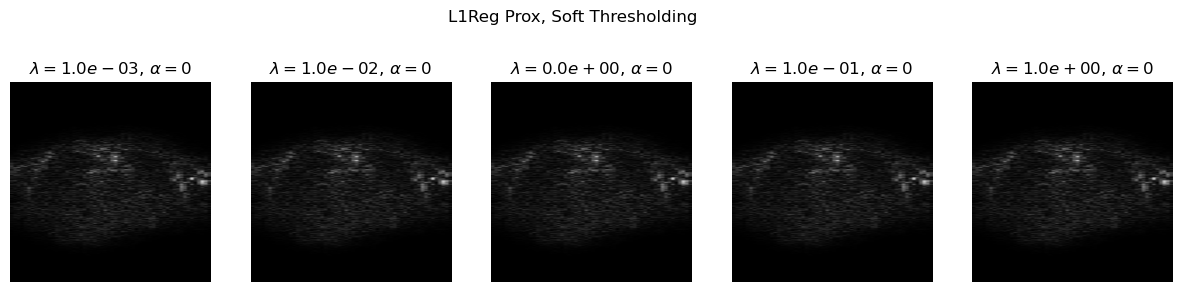

In [ ]:
import matplotlib.pyplot as plt
## Make Gradient operator (G)

def plot_proxg_lams(G, lams, grad, alpha=1, power=0.08):
    """ Plot an array of lams given wavelet transform"""
    fig, axes = plt.subplots(1, len(lams), figsize=(15, 3))

    for i, lam in enumerate(lams):
        proxg = sp.prox.L1Reg(G.oshape, lam)
        grad_thresh = proxg(alpha, grad)
        img_from_grad = G.H * grad_thresh
        img_from_grad = np.abs(img_from_grad)
        # axes[i].imshow(np.abs(wav_thresh[30, :, :])**power, cmap='gray')
        # axes[i].imshow(np.abs(img_from_grad[30, :, :]), cmap='gray')
        axes[i].imshow(np.rot90(img_from_grad[:, :, 256], k=-1), cmap='gray', aspect=58/512)
        axes[i].set_title(rf'$\lambda = {lam:.1e}$, $\alpha = {alpha}$')
        axes[i].axis('off')
    fig.suptitle(f'L1Reg Prox, Soft Thresholding', y=1.07)



lambdas_norm = [1e-3, 1e-2, 0, 0.1, 1]

plot_proxg_lams(G, lambdas_norm, grad_norm, alpha=1)

In [16]:
ksp_from_norm = A_sense * nufft_sense_norm
print(f'ksp_from_norm.shape')

ksp_from_norm.shape


In [17]:
print(f'ksp_from_norm.shape = {ksp_from_norm.shape}')

ksp_from_norm.shape = (15, 58, 400, 512)


In [18]:
print(f'A_sense = {A_sense}')

A_sense = <[15, 58, 400, 512]x[58, 512, 512]> NUFFT * Multiply Linop>


In [20]:
A_trial = sp.linop.Vstack([A_sense, G])
print(f'A_trial = {A_trial}')

A_trial = <[223789056]x[58, 512, 512]> Vstack Linop>


In [22]:
u_trial = np.zeros(A_trial.oshape, dtype=ksp_from_norm.dtype)
print(f'u_trial.shape = {u_trial.shape}')

u_trial.shape = (223789056,)


In [23]:
max_iter = 2
alpha = 1
lam = 1e-2
ksp = ksp_from_norm.astype(np.complex64)
x = np.zeros(A_sense.ishape, dtype=np.complex64)

proxg = sp.prox.L1Reg(G.oshape, lam)

In [24]:
print(f'proxg = {proxg}')

proxg = <[3, 58, 512, 512] L1Reg Prox>.


In [25]:
# max_iter = 2
# alpha = 1
# lam = 1e-2
# ksp = ksp_from_norm.astype(np.complex64)
# x = np.zeros(A_sense.ishape, dtype=np.complex64)

# proxg = sp.prox.L1Reg(G.oshape, lam)

def g(x):
    return lam*np.sum(np.abs(x)).item()

proxf1c = sp.prox.L2Reg(shape=ksp.shape, lamda=1, y=-ksp)
proxf2c = sp.prox.Conj(proxg)
proxfc = sp.prox.Stack([proxf1c, proxf2c])
proxg = sp.prox.NoOp(x.shape)
gamma_dual = 0
gamma_primal =0
sigma = 1

S = sp.linop.Multiply(A_trial.oshape, sigma)
AHA = A_trial.H * S * A_trial
max_eig = sp.app.MaxEig(
                AHA,
                dtype=x.dtype,
                max_iter=max_iter,
                show_pbar=True,
            ).run()

tau = 1/max_eig

MaxEig:   0%|          | 0/2 [00:00<?, ?it/s]

In [27]:
print(ksp.size + np.prod(G.oshape)) 

223789056


In [28]:
print(u_trial.size)

223789056


In [29]:
print(proxfc)

<[223789056] Stack Prox>.


In [30]:
alg = sp.alg.PrimalDualHybridGradient(
            proxfc,
            proxg,
            A_trial,
            A_trial.H,
            x,
            u_trial,
            tau,
            sigma,
            gamma_primal=gamma_primal,
            gamma_dual=gamma_dual,
            max_iter=max_iter,
        )

while not alg.done():
    alg.update()
    print('\rTotalVariation, Iteration={}'.format(alg.iter), end='')

result = alg.x
save_data_helpers.write_pickle(result, 'TV_2iters_try1.pkl')
print('PDHG Finished running.')

TotalVariation, Iteration=2Successfully saved as TV_2iters_try1.pkl
PDHG Finished running.


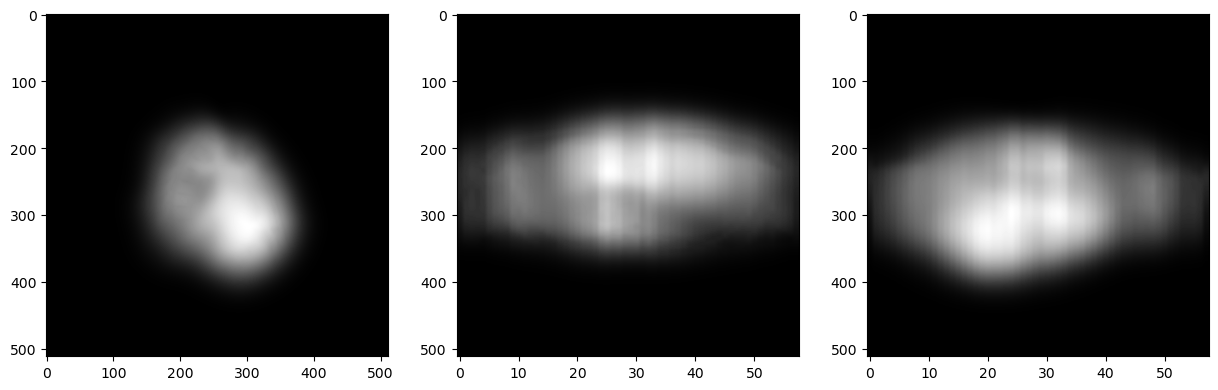

(<Figure size 1500x500 with 3 Axes>,
 array([<AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>], dtype=object))

In [31]:
recon_plot_helpers.plot_recons_all_axes(result)